In [1]:
from google.colab import files
uploaded = files.upload()

Saving House Price India.csv to House Price India.csv


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('House Price India.csv')


Q1. What is the average, median, and standard deviation of house prices?



### Answer:
The average, median, and standard deviation help us understand the overall distribution and variation of house prices.


In [3]:

average_price = df['Price'].mean()

median_price = df['Price'].median()

std_price = df['Price'].std()

print("Average Price:", average_price)

print("Median Price:", median_price)

print("Standard Deviation:", std_price)


Average Price: 538932.2183310534
Median Price: 450000.0
Standard Deviation: 367532.3808039669



### Interpretation:
- Average price shows the central value of house prices.
- Median shows the middle value.
- Standard deviation shows price variation across houses.


Q2. Which number of bedrooms is most common?



### Answer:
Mode is used to identify the most common number of bedrooms.


In [4]:

most_common_bedrooms = df['number of bedrooms'].mode()[0]

print("Most Common Number of Bedrooms:", most_common_bedrooms)


Most Common Number of Bedrooms: 3



### Interpretation:
The bedroom count with the highest frequency represents the most preferred house type.


Q3. Check if the price data is skewed.



### Answer:
Skewness helps determine whether the data distribution is symmetric or not.


In [5]:

price_skewness = df['Price'].skew()

print("Price Skewness:", price_skewness)


Price Skewness: 4.269297720707116



### Interpretation:
- Positive skewness means prices are right-skewed.
- Negative skewness means prices are left-skewed.
- Near zero indicates normal distribution.


Q4. What is the average price for each number of bedrooms?



### Answer:
Groupby operation is used to calculate average price based on bedroom count.


In [6]:

average_price_bedrooms = df.groupby('number of bedrooms')['Price'].mean()

average_price_bedrooms


,Price
number of bedrooms,
1,3.089638e+05
2,3.985476e+05
3,4.632776e+05
4,6.361988e+05
5,7.752550e+05
6,8.375815e+05
7,1.016544e+06
8,1.208455e+06
9,7.766663e+05



### Interpretation:
This analysis helps identify how bedroom count affects house prices.


Q5. What is the relationship between living area and price? (Use : Area without Basement).



### Answer:
Correlation and scatter plot are used to analyze the relationship between living area and price.


In [7]:

correlation = df['Area of the house(excluding basement)'].corr(df['Price'])

print("Correlation between Living Area and Price:", correlation)


Correlation between Living Area and Price: 0.6152204198678108


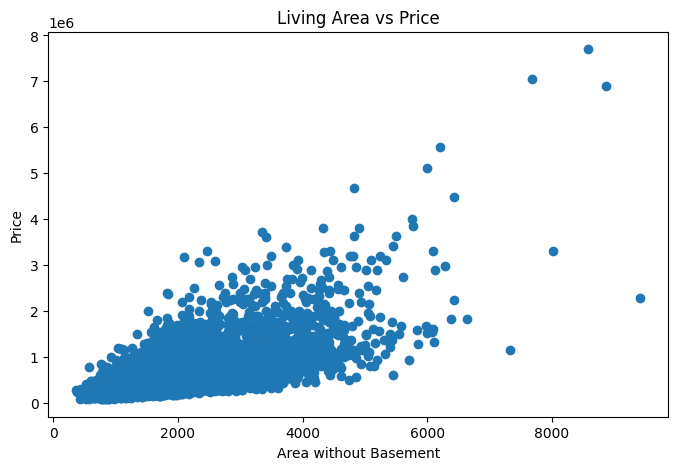

In [8]:

plt.figure(figsize=(8,5))

plt.scatter(
    df['Area of the house(excluding basement)'],
    df['Price']
)

plt.xlabel('Area without Basement')

plt.ylabel('Price')

plt.title('Living Area vs Price')

plt.show()



### Interpretation:
A positive correlation indicates that larger living areas generally have higher prices.


Q6. Identify any anomalies where houses have high prices but low areas.



### Answer:
Houses with unusually high prices and smaller areas are identified as anomalies.


In [9]:

anomalies = df[
    (df['Price'] > df['Price'].quantile(0.90)) &
    (df['Area of the house(excluding basement)'] <
     df['Area of the house(excluding basement)'].quantile(0.25))
]

anomalies[['Price', 'Area of the house(excluding basement)']].head()


,Price,Area of the house(excluding basement)
1125,970000,1130
1210,1180000,1090
1517,1180000,1100
2154,1150000,1130
8517,990000,930



### Interpretation:
These houses may have premium locations or luxury features despite smaller areas.


Q7. Compare average price based on number of floors and houses with or without waterfront.



### Answer:
Average price comparison helps understand the impact of floors and waterfront availability.


In [10]:

floor_price = df.groupby('number of floors')['Price'].mean()

waterfront_price = df.groupby('waterfront present')['Price'].mean()

print("Average Price Based on Floors:")

print(floor_price)

print("\nAverage Price Based on Waterfront:")

print(waterfront_price)


Average Price Based on Floors:
number of floors
1.0    4.369769e+05
1.5    5.549301e+05
2.0    6.487372e+05
2.5    1.106233e+06
3.0    5.663281e+05
3.5    1.205875e+06
Name: Price, dtype: float64

Average Price Based on Waterfront:
waterfront present
0    5.304174e+05
1    1.641902e+06
Name: Price, dtype: float64



### Interpretation:
Houses with more floors and waterfront views generally tend to have higher prices.


Q8. Identify the minimum and maximum house price. What does this indicate?



### Answer:
Minimum and maximum prices help understand the price range in the dataset.


In [11]:

minimum_price = df['Price'].min()

maximum_price = df['Price'].max()

print("Minimum House Price:", minimum_price)

print("Maximum House Price:", maximum_price)


Minimum House Price: 78000
Maximum House Price: 7700000



### Interpretation:
A large difference between minimum and maximum prices indicates significant variation in property values.


Q9. Which location (zipcode/area) has the highest average price?



### Answer:
Postal Code is used to identify the location with the highest average house price.


In [12]:

highest_price_location = df.groupby('Postal Code')['Price'].mean().sort_values(
    ascending=False
).head(1)

highest_price_location


,Price
Postal Code,
122071,2.348311e+06



### Interpretation:
The postal code with the highest average price represents a premium real estate area.


Q10. Write at least 5 insights from your analysis.



### Answer:

1. House prices show high variation across the dataset.

2. Houses with more bedrooms generally have higher prices.

3. Living area has a strong positive relationship with price.

4. Waterfront properties tend to be more expensive.

5. Some houses have unusually high prices despite smaller areas.

6. Premium postal code locations have significantly higher average prices.

7. Price distribution is positively skewed due to expensive luxury houses.
